<a href="https://colab.research.google.com/github/jasonkjw/daily_coding_commit/blob/main/HVAC_temp_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Mount Google Drive and Set Path
drive.mount('/content/drive')

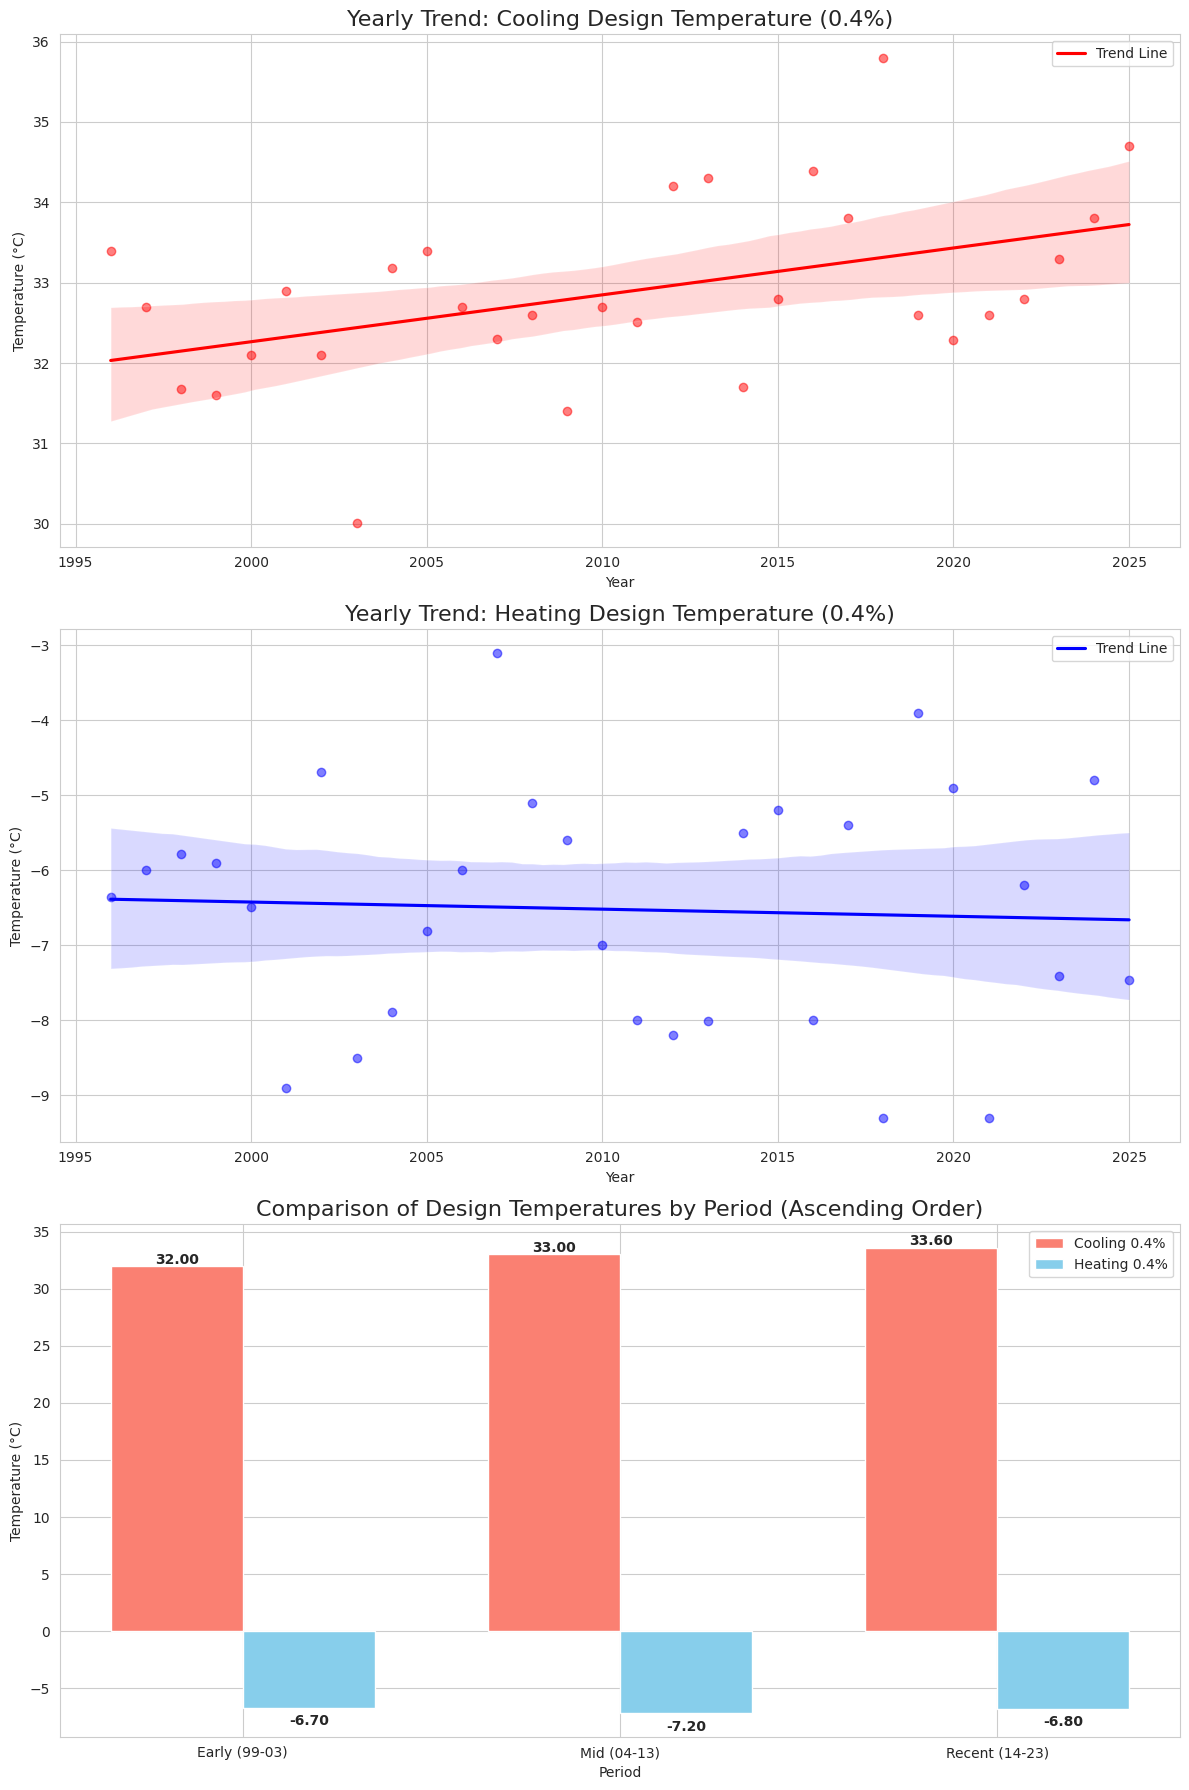


[Decadal Analysis Summary]
        Period  Cooling_04  Heating_04
 Early (99-03)        32.0        -6.7
   Mid (04-13)        33.0        -7.2
Recent (14-23)        33.6        -6.8


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import os

# 1. Set Path
file_path = '/content/drive/My Drive/Gwangju_STN_DATA.csv' # Adjust path if needed

def run_english_hvac_analysis(file_path):
    if not os.path.exists(file_path):
        print("File not found. Please check the path.")
        return

    # Load Data
    df = pd.read_csv(file_path)
    hourly_cols = [f'{i:02d}' for i in range(1, 25)]

    # --- [Analysis 1] Yearly Trend Extraction ---
    yearly_results = []
    for year in sorted(df['Year'].unique()):
        year_df = df[df['Year'] == year]
        temp_series = year_df[hourly_cols].stack()
        temp_series = temp_series[temp_series != -99.0].dropna()
        if len(temp_series) < 5000: continue

        yearly_results.append({
            'Year': year,
            'Cooling_04': temp_series.quantile(0.996),
            'Heating_04': temp_series.quantile(0.004)
        })
    yearly_df = pd.DataFrame(yearly_results)

    # --- [Analysis 2] Decadal Comparison (Past to Present) ---
    # Define time bins
    bins = [(1999, 2003), (2004, 2013), (2014, 2023)]
    bin_labels = ['Early (99-03)', 'Mid (04-13)', 'Recent (14-23)']
    decadal_results = []

    for (start, end), label in zip(bins, bin_labels):
        mask = (df['Year'] >= start) & (df['Year'] <= end)
        period_data = df[mask][hourly_cols].stack()
        period_data = period_data[period_data != -99.0].dropna()

        decadal_results.append({
            'Period': label,
            'Cooling_04': period_data.quantile(0.996),
            'Heating_04': period_data.quantile(0.004)
        })
    decadal_df = pd.DataFrame(decadal_results)

    # --- [Visualization] ---
    fig, axes = plt.subplots(3, 1, figsize=(12, 18))
    sns.set_style("whitegrid")

    # Graph 1: Yearly Cooling Trend (Upper 0.4%)
    sns.regplot(data=yearly_df, x='Year', y='Cooling_04', ax=axes[0], color='red',
                scatter_kws={'alpha':0.5}, line_kws={'label':'Trend Line'})
    axes[0].set_title('Yearly Trend: Cooling Design Temperature (0.4%)', fontsize=16)
    axes[0].set_ylabel('Temperature (°C)')
    axes[0].set_xlabel('Year')
    axes[0].legend()

    # Graph 2: Yearly Heating Trend (Lower 0.4%)
    sns.regplot(data=yearly_df, x='Year', y='Heating_04', ax=axes[1], color='blue',
                scatter_kws={'alpha':0.5}, line_kws={'label':'Trend Line'})
    axes[1].set_title('Yearly Trend: Heating Design Temperature (0.4%)', fontsize=16)
    axes[1].set_ylabel('Temperature (°C)')
    axes[1].set_xlabel('Year')
    axes[1].legend()

    # Graph 3: Decadal Comparison (From Past to Recent)
    x = np.arange(len(bin_labels))
    width = 0.35
    axes[2].bar(x - width/2, decadal_df['Cooling_04'], width, label='Cooling 0.4%', color='salmon')
    axes[2].bar(x + width/2, decadal_df['Heating_04'], width, label='Heating 0.4%', color='skyblue')

    # Add numeric labels on top of bars
    for i, v in enumerate(decadal_df['Cooling_04']):
        axes[2].text(i - width/2, v + 0.2, f'{v:.2f}', ha='center', fontweight='bold')
    for i, v in enumerate(decadal_df['Heating_04']):
        offset = -1.5 if v < 0 else 0.2
        axes[2].text(i + width/2, v + offset, f'{v:.2f}', ha='center', fontweight='bold')

    axes[2].set_xticks(x)
    axes[2].set_xticklabels(bin_labels)
    axes[2].set_title('Comparison of Design Temperatures by Period (Ascending Order)', fontsize=16)
    axes[2].set_ylabel('Temperature (°C)')
    axes[2].set_xlabel('Period')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    # Print Result Dataframe
    print("\n[Decadal Analysis Summary]")
    print(decadal_df.to_string(index=False))

# Execute
run_english_hvac_analysis(file_path)